# 05 — Exploratory Analysis

This notebook queries the Divvy warehouse built in notebooks 02 through 04. PostgreSQL performs the aggregations and Python visualizes the compact results.

It answers: member versus casual behavior; ride volume and duration by day, hour, month, and bike type; most-used stations and station net flows; seasonal patterns and anomalies; and round-trip behavior.

Run notebook 04 before interpreting results. ETL-flagged anomalies are excluded by default. Valid trips without station IDs remain in system-wide measures, but station metrics only include records with the relevant station key.

### Imports, Configuration, and Helpers

In [1]:
import os
import warnings
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from IPython.display import Markdown, display
import config

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
BASE_FOLDER = r"G:\My Drive\divvy_tripdata"
REPORTS_FOLDER = os.path.join(BASE_FOLDER, "exploratory_analysis_reports")
os.makedirs(REPORTS_FOLDER, exist_ok=True)
SCHEMA = "divvy"
EXCLUDE_FLAGGED_ANOMALIES = True
MIN_DURATION_MINUTES = None
MAX_DURATION_MINUTES = None
TOP_N_STATIONS = 15
RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat(timespec="seconds")

def run_query(sql, params=None):
    try:
        conn = psycopg2.connect(**config.config_divvy())
        return pd.read_sql_query(sql, conn, params=params)
    except Exception as error:
        raise ConnectionError(f"Could not query divvy_db: {error}") from error
    finally:
        if "conn" in locals():
            conn.close()

def savefig(filename):
    path = os.path.join(REPORTS_FOLDER, filename)
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("Saved:", path)

filters = ["f.duration_minutes > 0"]
if EXCLUDE_FLAGGED_ANOMALIES: filters.append("COALESCE(f.is_anomalous, FALSE) = FALSE")
if MIN_DURATION_MINUTES is not None: filters.append(f"f.duration_minutes >= {float(MIN_DURATION_MINUTES)}")
if MAX_DURATION_MINUTES is not None: filters.append(f"f.duration_minutes <= {float(MAX_DURATION_MINUTES)}")
WHERE = " AND ".join(filters)
print("Reports:", REPORTS_FOLDER, "\nPopulation:", WHERE)

Reports: G:\My Drive\divvy_tripdata\exploratory_analysis_reports 
Population: f.duration_minutes > 0 AND COALESCE(f.is_anomalous, FALSE) = FALSE


## 1. Coverage, warehouse views, and member versus casual behavior

,total_trips,first_start,last_start,active_dates,member_segments,bike_types,flagged_anomaly_pct,missing_station_pct
0,14802126,2024-01-01 06:00:39+00:00,2026-08-01 04:58:05.898000+00:00,943,2,3,2.584764,31.216448


,full_date,member_casual,ride_count,avg_duration_minutes
0,2026-07-31,casual,11598,15.992442
1,2026-07-31,member,15369,11.723441
2,2026-07-30,casual,13009,19.494988
3,2026-07-30,member,20223,12.796629
4,2026-07-29,casual,11300,18.668096
5,2026-07-29,member,20688,12.846428
6,2026-07-28,casual,9043,18.840343
7,2026-07-28,member,18922,12.426958
8,2026-07-27,casual,4702,20.104917
9,2026-07-27,member,11110,11.402431


,member_casual,rides,avg_duration_min,median_duration_min,p95_duration_min,weekend_ride_pct,round_trip_pct,ride_share_pct
0,member,9269033,12.26,8.77,31.31,23.59,1.62,64.28
1,casual,5150493,20.28,11.98,60.43,37.37,5.78,35.72


Saved: G:\My Drive\divvy_tripdata\exploratory_analysis_reports\01_member_casual.png


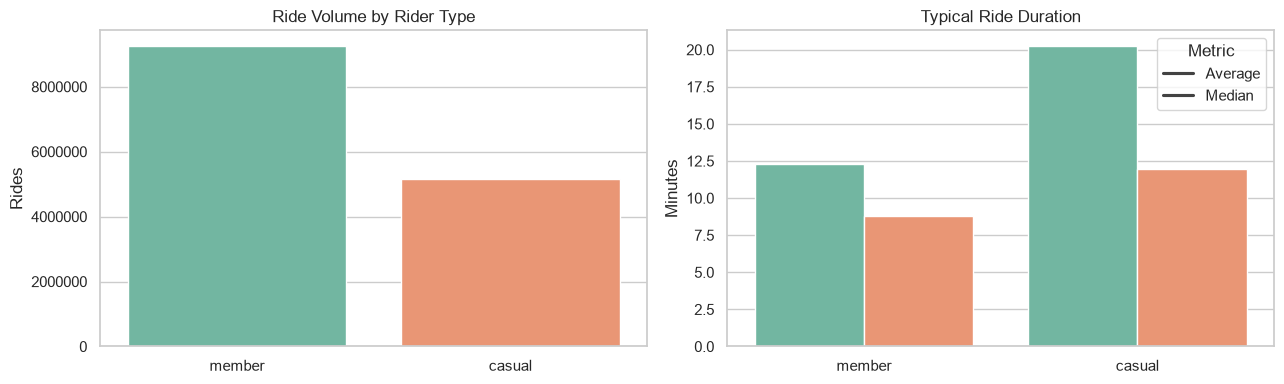

In [2]:
coverage = run_query(f'''
SELECT COUNT(*) total_trips, MIN(started_at) first_start, MAX(started_at) last_start,
 COUNT(DISTINCT start_date_key) active_dates, COUNT(DISTINCT member_type_key) member_segments,
 COUNT(DISTINCT ride_type_key) bike_types, AVG((is_anomalous IS TRUE)::int)*100 flagged_anomaly_pct,
 AVG((start_station_key IS NULL OR end_station_key IS NULL)::int)*100 missing_station_pct
FROM {SCHEMA}.fact_trip;
''')
display(coverage)
display(run_query(f"SELECT full_date, member_casual, ride_count, avg_duration_minutes FROM {SCHEMA}.vw_daily_rides ORDER BY full_date DESC, member_casual LIMIT 10"))

segments = run_query(f'''
SELECT mt.member_casual, COUNT(*) rides, AVG(f.duration_minutes) avg_duration_min,
 PERCENTILE_CONT(.5) WITHIN GROUP (ORDER BY f.duration_minutes) median_duration_min,
 PERCENTILE_CONT(.95) WITHIN GROUP (ORDER BY f.duration_minutes) p95_duration_min,
 AVG(d.is_weekend::int)*100 weekend_ride_pct, AVG(COALESCE(f.is_round_trip,FALSE)::int)*100 round_trip_pct
FROM {SCHEMA}.fact_trip f JOIN {SCHEMA}.dim_member_type mt ON f.member_type_key=mt.member_type_key
JOIN {SCHEMA}.dim_date d ON f.start_date_key=d.date_key WHERE {WHERE}
GROUP BY mt.member_casual ORDER BY rides DESC;
''')
segments["ride_share_pct"] = 100*segments.rides/segments.rides.sum()
display(segments.round(2))
fig,axes=plt.subplots(1,2,figsize=(13,4))
sns.barplot(data=segments,x="member_casual",y="rides",hue="member_casual",legend=False,palette="Set2",ax=axes[0])
axes[0].set(title="Ride Volume by Rider Type",xlabel="",ylabel="Rides"); axes[0].ticklabel_format(style="plain",axis="y")
plot=segments.melt(id_vars="member_casual",value_vars=["avg_duration_min","median_duration_min"])
sns.barplot(data=plot,x="member_casual",y="value",hue="variable",palette="Set2",ax=axes[1])
axes[1].set(title="Typical Ride Duration",xlabel="",ylabel="Minutes"); axes[1].legend(title="Metric",labels=["Average","Median"])
plt.tight_layout(); savefig("01_member_casual.png"); plt.show()

## 2. Timing, seasonality, and bike types

In [ ]:
profiles = run_query(f'''
SELECT d.full_date,d.day_of_week,d.day_name,d.year,d.month,d.month_name,f.start_hour,mt.member_casual,rt.rideable_type,
 COUNT(*) rides,AVG(f.duration_minutes) avg_duration_min
FROM {SCHEMA}.fact_trip f JOIN {SCHEMA}.dim_date d ON f.start_date_key=d.date_key
JOIN {SCHEMA}.dim_member_type mt ON f.member_type_key=mt.member_type_key
JOIN {SCHEMA}.dim_ride_type rt ON f.ride_type_key=rt.ride_type_key WHERE {WHERE}
GROUP BY d.full_date,d.day_of_week,d.day_name,d.year,d.month,d.month_name,f.start_hour,mt.member_casual,rt.rideable_type;
''')
order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
daily=profiles.groupby(["day_of_week","day_name","member_casual"],as_index=False).agg(rides=("rides","sum"),duration=("avg_duration_min","mean"))
daily["day_name"]=pd.Categorical(daily.day_name,categories=order,ordered=True)
hourly=profiles.groupby(["start_hour","member_casual"],as_index=False).agg(rides=("rides","sum"),duration=("avg_duration_min","mean"))
monthly=profiles.groupby(["year","month","member_casual"],as_index=False).agg(rides=("rides","sum"),duration=("avg_duration_min","mean"))
monthly["date"]=pd.to_datetime(dict(year=monthly.year,month=monthly.month,day=1))
bike=profiles.groupby(["rideable_type","member_casual"],as_index=False).agg(rides=("rides","sum"),duration=("avg_duration_min","mean"))

fig,axes=plt.subplots(2,3,figsize=(18,9))
sns.lineplot(data=daily.sort_values("day_of_week"),x="day_name",y="rides",hue="member_casual",marker="o",ax=axes[0,0]); axes[0,0].set(title="Volume by Day",xlabel="",ylabel="Rides"); axes[0,0].tick_params(axis="x",rotation=30)
sns.lineplot(data=daily.sort_values("day_of_week"),x="day_name",y="duration",hue="member_casual",marker="o",ax=axes[0,1]); axes[0,1].set(title="Duration by Day",xlabel="",ylabel="Minutes"); axes[0,1].tick_params(axis="x",rotation=30)
sns.lineplot(data=hourly,x="start_hour",y="rides",hue="member_casual",marker="o",ax=axes[0,2]); axes[0,2].set(title="Volume by Hour",xlabel="Start hour",ylabel="Rides",xticks=range(0,24,2))
sns.lineplot(data=hourly,x="start_hour",y="duration",hue="member_casual",marker="o",ax=axes[1,0]); axes[1,0].set(title="Duration by Hour",xlabel="Start hour",ylabel="Minutes",xticks=range(0,24,2))
sns.lineplot(data=monthly,x="date",y="rides",hue="member_casual",marker="o",ax=axes[1,1]); axes[1,1].set(title="Monthly Volume",xlabel="",ylabel="Rides"); axes[1,1].tick_params(axis="x",rotation=30)
sns.barplot(data=bike,x="rideable_type",y="rides",hue="member_casual",ax=axes[1,2]); axes[1,2].set(title="Bike-Type Mix",xlabel="Bike type",ylabel="Rides")
plt.tight_layout(); savefig("02_time_and_bike_patterns.png"); plt.show()
display(bike.sort_values(["rideable_type","rides"],ascending=[True,False]))

## 3. Station activity and net flows

In [ ]:
display(run_query(f"SELECT station_id,station_name,full_date,rides_started,rides_ended,net_outflow FROM {SCHEMA}.vw_station_flow ORDER BY full_date DESC,ABS(net_outflow) DESC LIMIT 10"))
station_flow=run_query(f'''
WITH starts AS (SELECT start_station_key station_key,COUNT(*) rides_started FROM {SCHEMA}.fact_trip f WHERE {WHERE} AND start_station_key IS NOT NULL GROUP BY start_station_key),
ends AS (SELECT end_station_key station_key,COUNT(*) rides_ended FROM {SCHEMA}.fact_trip f WHERE {WHERE} AND end_station_key IS NOT NULL GROUP BY end_station_key)
SELECT s.station_id,s.station_name,COALESCE(st.rides_started,0) rides_started,COALESCE(en.rides_ended,0) rides_ended,
 COALESCE(st.rides_started,0)-COALESCE(en.rides_ended,0) net_outflow,COALESCE(st.rides_started,0)+COALESCE(en.rides_ended,0) total_activity
FROM {SCHEMA}.dim_station s LEFT JOIN starts st ON s.station_key=st.station_key LEFT JOIN ends en ON s.station_key=en.station_key
WHERE COALESCE(st.rides_started,0)+COALESCE(en.rides_ended,0)>0 ORDER BY total_activity DESC;
''')
display(station_flow.head(TOP_N_STATIONS))
top=station_flow.head(TOP_N_STATIONS).sort_values("total_activity")
flows=pd.concat([station_flow.nsmallest(TOP_N_STATIONS,"net_outflow"),station_flow.nlargest(TOP_N_STATIONS,"net_outflow")]).drop_duplicates().sort_values("net_outflow")
fig,axes=plt.subplots(1,2,figsize=(18,8))
names=top.station_name.fillna(top.station_id); axes[0].barh(names,top.rides_started,label="Starts"); axes[0].barh(names,top.rides_ended,left=top.rides_started,label="Ends")
axes[0].set(title="Most-Used Stations",xlabel="Rides",ylabel=""); axes[0].legend()
axes[1].barh(flows.station_name.fillna(flows.station_id),flows.net_outflow,color=np.where(flows.net_outflow>=0,"#E45756","#54A24B")); axes[1].axvline(0,color="black",lw=.8)
axes[1].set(title="Largest Net Flows (starts minus ends)",xlabel="Net outflow",ylabel="")
plt.tight_layout(); savefig("03_station_flows.png"); plt.show()

## 4. Seasonal anomalies and round-trip behavior

In [ ]:
trends=run_query(f'''
SELECT d.full_date,mt.member_casual,COUNT(*) rides,AVG(COALESCE(f.is_anomalous,FALSE)::int)*100 flagged_anomaly_pct
FROM {SCHEMA}.fact_trip f JOIN {SCHEMA}.dim_date d ON f.start_date_key=d.date_key
JOIN {SCHEMA}.dim_member_type mt ON f.member_type_key=mt.member_type_key WHERE f.duration_minutes>0
GROUP BY d.full_date,mt.member_casual ORDER BY d.full_date,mt.member_casual;
''')
trends.full_date=pd.to_datetime(trends.full_date)
trends["baseline"]=trends.groupby("member_casual").rides.transform(lambda x:x.rolling(28,min_periods=14).mean())
trends["std"]=trends.groupby("member_casual").rides.transform(lambda x:x.rolling(28,min_periods=14).std())
trends["z_score"]=(trends.rides-trends.baseline)/trends["std"]
anomalies=trends[trends.z_score.abs()>=3].sort_values("z_score",key=lambda x:x.abs(),ascending=False)
display(anomalies.head(20))
fig,ax=plt.subplots(figsize=(15,5)); sns.lineplot(data=trends,x="full_date",y="rides",hue="member_casual",alpha=.35,ax=ax); sns.lineplot(data=trends,x="full_date",y="baseline",hue="member_casual",legend=False,lw=2.5,ax=ax)
if not anomalies.empty: sns.scatterplot(data=anomalies,x="full_date",y="rides",hue="member_casual",legend=False,s=65,ax=ax)
ax.set(title="Daily Rides and 28-Day Baseline (points: absolute z score at least 3)",xlabel="",ylabel="Rides")
plt.tight_layout(); savefig("04_daily_anomalies.png"); plt.show()

round_trips=run_query(f'''
SELECT mt.member_casual,rt.rideable_type,d.is_weekend,COUNT(*) all_rides,
 COUNT(*) FILTER (WHERE COALESCE(f.is_round_trip,FALSE)) round_trip_rides,
 AVG(f.duration_minutes) FILTER (WHERE COALESCE(f.is_round_trip,FALSE)) round_trip_avg_duration_min,
 100.0*COUNT(*) FILTER (WHERE COALESCE(f.is_round_trip,FALSE))/COUNT(*) round_trip_pct
FROM {SCHEMA}.fact_trip f JOIN {SCHEMA}.dim_member_type mt ON f.member_type_key=mt.member_type_key
JOIN {SCHEMA}.dim_ride_type rt ON f.ride_type_key=rt.ride_type_key JOIN {SCHEMA}.dim_date d ON f.start_date_key=d.date_key
WHERE {WHERE} GROUP BY mt.member_casual,rt.rideable_type,d.is_weekend ORDER BY round_trip_pct DESC;
''')
display(round_trips.round(2))
fig,ax=plt.subplots(figsize=(10,5)); sns.barplot(data=round_trips,x="rideable_type",y="round_trip_pct",hue="member_casual",ax=ax)
ax.set(title="Round-Trip Rate by Bike Type and Rider",xlabel="Bike type",ylabel="Round-trip rides percent")
plt.tight_layout(); savefig("05_round_trip_behavior.png"); plt.show()

## 5. Reproducible findings summary and interpretation notes

In [ ]:
outflow=station_flow.loc[station_flow.net_outflow.idxmax()]; inflow=station_flow.loc[station_flow.net_outflow.idxmin()]
peak_hour=hourly.groupby("start_hour",as_index=False).rides.sum().nlargest(1,"rides").iloc[0]
peak_month=monthly.groupby("date",as_index=False).rides.sum().nlargest(1,"rides").iloc[0]
facts=[f"Analysis run: {RUN_TIMESTAMP}",f"Valid analysis trips: {int(segments.rides.sum()):,}",f"Peak hour: {int(peak_hour.start_hour):02d}:00",f"Peak month: {peak_month.date:%B %Y}",f"Largest net outflow: {outflow.station_name or outflow.station_id} ({int(outflow.net_outflow):,})",f"Largest net inflow: {inflow.station_name or inflow.station_id} ({int(inflow.net_outflow):,})",f"Statistical anomaly rows: {len(anomalies):,}"]
display(Markdown("### Key outputs\n"+"\n".join("- "+x for x in facts)))
for name,frame in {"member_casual_summary":segments,"bike_type_summary":bike,"station_flow_summary":station_flow,"daily_statistical_anomalies":anomalies}.items(): frame.to_csv(os.path.join(REPORTS_FOLDER,name+".csv"),index=False)
print("Saved tables and five figures to:",REPORTS_FOLDER)

Interpretation: compare average and median duration together; a gap implies a long tail. Net outflow is a rebalancing signal, not a station-quality score. A z score detects unusual demand relative to each segment's recent 28-day baseline, not its cause. Round-trip fields use the ETL's station-based definition, so review station completeness in notebook 04. Re-run after every ETL load to refresh outputs.